<h1 style="color:red;text-align:center;background-color:black;">AI Resume Screening System</h1>

DATASET INFORMATION
Total resumes : 139
Categories    : 16

category
Web Development            13
DevOps                     11
Data Science               10
Cybersecurity              10
Artificial Intelligence    10
Database Engineering        9
Embedded Systems            9
Game Development            8
UI/UX Design                8
Blockchain                  8
QA & Testing                8
Product Management          8
Systems Programming         8
AR/VR Development           7
Developer Relations         7
Mobile Development          5

CLEANED TEXT SAMPLE
Before:
Python machine learning deep learning TensorFlow scikit-learn pandas numpy SQL NLP AWS tableau statistics

After:
python machine learning deep learning tensorflow scikitlearn panda numpy sql nlp aws tableau statistic

LABEL INFORMATION
Total classes: 16
Class distribution:
Counter({15: 13, 6: 11, 4: 10, 3: 10, 1: 10, 5: 9, 8: 9, 9: 8, 14: 8, 2: 8, 12: 8, 11: 8, 13: 8, 0: 7, 7: 7, 10: 5})

Label mapping:
0 -> AR/VR Deve

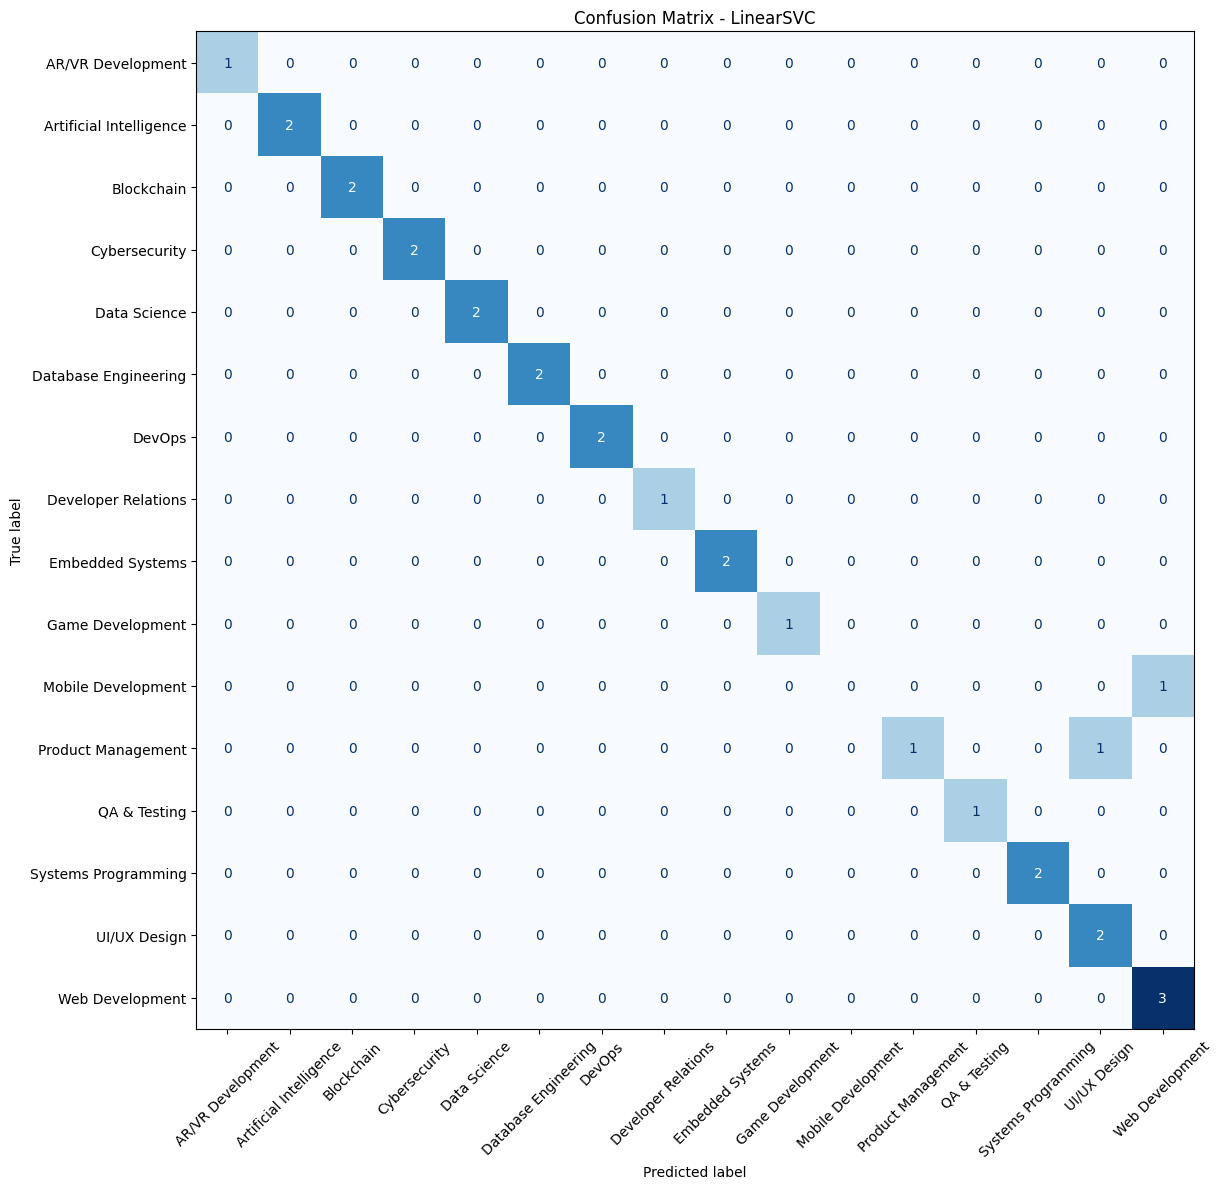

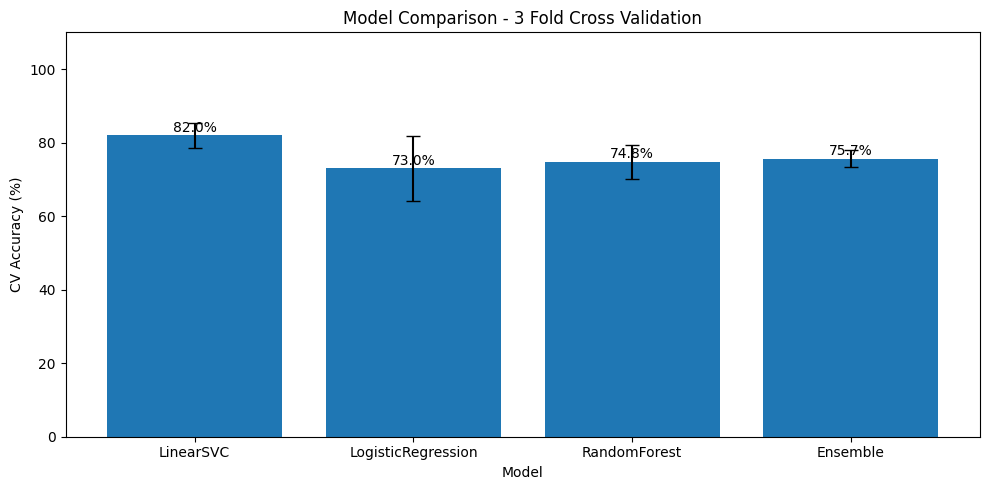


TEST PREDICTIONS

Expected: Data Science

RESUME PREDICTION
Cleaned text:
python developer skilled machine learning deep learning pytorch fastapi nlp tensorflow rest apis panda scikitlearn

Rank    Category                      Confidence
------------------------------------------------------------
1       Data Science                   43.01%  ████████
2       Artificial Intelligence        23.18%  ████
3       Web Development                 5.16%  █
Predicted: Data Science

Expected: Web Development

RESUME PREDICTION
Cleaned text:
built full stack application using react nodejs mongodb express experience html cs rest api aws

Rank    Category                      Confidence
------------------------------------------------------------
1       Web Development                66.44%  █████████████
2       Blockchain                      3.07%  
3       Mobile Development              3.05%  
Predicted: Web Development

Expected: Cybersecurity

RESUME PREDICTION
Cleaned text:
penetrati

In [3]:
import re
import pickle
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import nltk
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.calibration import CalibratedClassifierCV

warnings.filterwarnings("ignore")

for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet"]:
    nltk.download(pkg, quiet=True)


lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))


TECH_KEEP = {
    "c",
    "cpp",
    "csharp",
    "r",
    "go",
    "rust",
    "php",
    "sql",
    "bash",
    "perl",
    "lua",
    "dart",
    "swift",
    "java",
    "javascript",
    "typescript",

    "ai",
    "ml",
    "dl",
    "nlp",
    "llm",
    "rag",
    "cv",
    "cnn",
    "rnn",
    "lstm",
    "gru",
    "gan",
    "gpt",
    "bert",
    "ner",
    "ocr",
    "asr",
    "t5",

    "db",
    "nosql",
    "etl",
    "olap",
    "oltp",
    "bi",
    "eda",
    "csv",
    "json",
    "xml",
    "api",

    "aws",
    "gcp",
    "azure",
    "ec2",
    "s3",
    "iam",
    "eks",
    "ecs",
    "vpc",
    "cdn",
    "dns",
    "vm",

    "git",
    "svn",
    "ci",
    "cd",
    "cicd",
    "devops",
    "docker",
    "k8s",
    "kubernetes",
    "jenkins",
    "helm",
    "ansible",
    "terraform",

    "html",
    "css",
    "js",
    "ts",
    "rest",
    "http",
    "https",
    "url",
    "uri",
    "dom",
    "ajax",
    "seo",

    "ui",
    "ux",
    "oop",
    "orm",
    "sdk",
    "ide",
    "npm",
    "pip",
    "pypi",
    "cli",
    "gui",

    "mysql",
    "dbms",
    "rdbms",
    "mongodb",
    "redis",
    "neo4j",
    "cassandra",
    "dynamodb",

    "os",
    "cpu",
    "gpu",
    "ram",
    "rom",
    "ssd",
    "tcp",
    "udp",
    "ip",
    "ssh",
    "ftp",
    "vpn",
    "lan",
    "wan",

    "dsa",
    "ds",
    "algo",
    "mvc",
    "mvp",
    "mvvm",
    "solid",
    "dry",
    "kiss",

    "ssl",
    "tls",
    "jwt",
    "oauth",
    "sso",
    "mfa",
    "2fa",

    "ios",
    "apk",

    "qa",
    "uat",
    "po",
    "pm",
    "saas",
    "paas",
    "iaas"
}


def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+|www\S+", " ", text)

    text = re.sub(r"\S+@\S+", " ", text)

    replacements = {
        "c++": " cpp ",
        "c#": " csharp ",
        ".net": " dotnet ",
        "node.js": " nodejs ",
        "next.js": " nextjs ",
        "react.js": " reactjs ",
        "vue.js": " vuejs ",
        "web3.js": " web3js ",
        "scikit-learn": " scikitlearn ",
        "github actions": " githubactions ",
        "machine-learning": " machinelearning ",
        "deep-learning": " deeplearning ",
        "computer-vision": " computervision ",
        "natural-language-processing": " naturallanguageprocessing "
    }

    for old, new in replacements.items():
        text = text.replace(old, new)

    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    words = word_tokenize(text)

    cleaned_words = []

    for word in words:

        if word in stop_words and word not in TECH_KEEP:
            continue

        if len(word) == 1 and word not in TECH_KEEP:
            continue

        cleaned_words.append(word)

    cleaned_words = [
        lemmatizer.lemmatize(word)
        for word in cleaned_words
    ]

    return " ".join(cleaned_words)


resume_data = [

    {
        "resume": "Python machine learning deep learning TensorFlow scikit-learn pandas numpy SQL NLP AWS tableau statistics",
        "category": "Data Science"
    },

    {
        "resume": "Machine learning engineer TensorFlow PyTorch Docker Kubernetes NLP computer vision",
        "category": "Data Science"
    },

    {
        "resume": "Data scientist R Python statistical modeling regression clustering A/B testing Jupyter hypothesis testing",
        "category": "Data Science"
    },

    {
        "resume": "Big data Spark Hadoop Hive Kafka data pipeline ETL Airflow Scala distributed computing",
        "category": "Data Science"
    },

    {
        "resume": "Business intelligence Power BI Tableau SQL data warehouse Snowflake DAX reporting dashboards",
        "category": "Data Science"
    },

    {
        "resume": "Python pandas numpy matplotlib seaborn scikit-learn machine learning data preprocessing feature engineering model evaluation",
        "category": "Data Science"
    },

    {
        "resume": "Data analyst SQL Excel Python pandas data visualization Power BI Tableau business analytics KPI reporting",
        "category": "Data Science"
    },

    {
        "resume": "Machine learning regression classification decision trees random forest XGBoost cross validation hyperparameter tuning",
        "category": "Data Science"
    },

    {
        "resume": "Statistics probability hypothesis testing ANOVA correlation covariance regression predictive analytics Python",
        "category": "Data Science"
    },

    {
        "resume": "Data scientist NLP text classification sentiment analysis TF-IDF machine learning Python Jupyter scikit-learn",
        "category": "Data Science"
    },

    {
        "resume": "React JavaScript Node.js MongoDB Express HTML CSS REST API",
        "category": "Web Development"
    },

    {
        "resume": "Frontend developer React Vue TypeScript HTML CSS UI UX",
        "category": "Web Development"
    },

    {
        "resume": "Full stack Django Python PostgreSQL Redis Celery Docker REST GraphQL",
        "category": "Web Development"
    },

    {
        "resume": "Backend engineer Java Spring Boot Hibernate Microservices Kafka REST API Maven",
        "category": "Web Development"
    },

    {
        "resume": "PHP Laravel MySQL WordPress REST API Composer MVC Bootstrap AJAX",
        "category": "Web Development"
    },

    {
        "resume": "Ruby Rails PostgreSQL RSpec Sidekiq Heroku REST API MVC",
        "category": "Web Development"
    },

    {
        "resume": "Next.js React TypeScript Tailwind CSS Vercel GraphQL Apollo headless CMS",
        "category": "Web Development"
    },

    {
        "resume": "ASP.NET C# MVC Entity Framework SQL Server Azure DevOps Blazor REST API",
        "category": "Web Development"
    },

    {
        "resume": "JavaScript React Node.js Express MongoDB REST API GitHub frontend backend full stack development",
        "category": "Web Development"
    },

    {
        "resume": "Python Flask Django HTML CSS JavaScript PostgreSQL REST API backend web development",
        "category": "Web Development"
    },

    {
        "resume": "React TypeScript Redux JavaScript HTML CSS responsive web applications frontend development",
        "category": "Web Development"
    },

    {
        "resume": "Node.js Express PostgreSQL MongoDB REST GraphQL authentication authorization backend development",
        "category": "Web Development"
    },

    {
        "resume": "Django Python PostgreSQL HTML CSS JavaScript Bootstrap REST API web application development",
        "category": "Web Development"
    },

    {
        "resume": "Ethical hacking penetration testing Kali Linux Wireshark CEH firewall security",
        "category": "Cybersecurity"
    },

    {
        "resume": "Cloud security AWS Azure DevSecOps encryption IAM threat modeling",
        "category": "Cybersecurity"
    },

    {
        "resume": "SOC analyst SIEM Splunk threat hunting incident response malware analysis forensics",
        "category": "Cybersecurity"
    },

    {
        "resume": "Network security firewall IDS IPS VPN zero trust CISSP NIST compliance",
        "category": "Cybersecurity"
    },

    {
        "resume": "Application security OWASP SAST DAST secure SDLC vulnerability management burp suite",
        "category": "Cybersecurity"
    },

    {
        "resume": "Cybersecurity penetration testing vulnerability assessment Kali Linux Nmap Metasploit Burp Suite security auditing",
        "category": "Cybersecurity"
    },

    {
        "resume": "SOC security analyst SIEM Splunk threat detection incident response security monitoring log analysis",
        "category": "Cybersecurity"
    },

    {
        "resume": "Network security TCP IP firewall VPN IDS IPS intrusion detection network monitoring Wireshark",
        "category": "Cybersecurity"
    },

    {
        "resume": "Ethical hacking Linux penetration testing vulnerability scanning OWASP web application security",
        "category": "Cybersecurity"
    },

    {
        "resume": "Digital forensics malware analysis incident response threat intelligence endpoint security cybersecurity",
        "category": "Cybersecurity"
    },

    {
        "resume": "AWS Docker Kubernetes Jenkins Terraform Linux CI CD DevOps",
        "category": "DevOps"
    },

    {
        "resume": "Cloud architect Lambda Docker Kubernetes networking VPC serverless",
        "category": "DevOps"
    },

    {
        "resume": "Azure DevOps pipelines ARM templates AKS Helm GitOps monitoring Prometheus Grafana",
        "category": "DevOps"
    },

    {
        "resume": "GCP Google Cloud Run BigQuery Pub/Sub Terraform Anthos SRE observability",
        "category": "DevOps"
    },

    {
        "resume": "Site reliability engineer SLO SLI error budget chaos engineering on-call incident management",
        "category": "DevOps"
    },

    {
        "resume": "Platform engineer Backstage developer portal internal tools Crossplane GitOps ArgoCD",
        "category": "DevOps"
    },

    {
        "resume": "AWS Docker Kubernetes Jenkins GitHub Actions CI CD Terraform Ansible Linux automation",
        "category": "DevOps"
    },

    {
        "resume": "AWS EC2 S3 Lambda CloudFormation Docker Kubernetes Jenkins continuous integration deployment monitoring",
        "category": "DevOps"
    },

    {
        "resume": "Kubernetes Helm Docker ArgoCD GitOps Prometheus Grafana container orchestration DevOps",
        "category": "DevOps"
    },

    {
        "resume": "Terraform AWS Azure infrastructure as code Ansible Linux cloud automation CI CD pipelines",
        "category": "DevOps"
    },

    {
        "resume": "SRE Kubernetes observability Prometheus Grafana logging monitoring incident response reliability engineering",
        "category": "DevOps"
    },

    {
        "resume": "Android developer Kotlin Java Firebase XML Android SDK push notifications",
        "category": "Mobile Development"
    },

    {
        "resume": "Swift iOS developer UIKit SwiftUI Core Data Xcode App Store",
        "category": "Mobile Development"
    },

    {
        "resume": "Flutter Dart cross-platform iOS Android Firebase REST API state management BLoC",
        "category": "Mobile Development"
    },

    {
        "resume": "React Native JavaScript iOS Android Expo Redux TypeScript mobile UI",
        "category": "Mobile Development"
    },

    {
        "resume": "Android developer Kotlin Jetpack Compose Room API integration Firebase MVVM architecture",
        "category": "Mobile Development"
    },

    {
        "resume": "LLM fine-tuning prompt engineering RAG LangChain OpenAI GPT vector database embeddings",
        "category": "Artificial Intelligence"
    },

    {
        "resume": "Computer vision OpenCV YOLO image segmentation object detection PyTorch CNN",
        "category": "Artificial Intelligence"
    },

    {
        "resume": "Reinforcement learning reward modeling policy gradient Q-learning OpenAI Gym agent simulation",
        "category": "Artificial Intelligence"
    },

    {
        "resume": "Generative AI diffusion models Stable Diffusion GANs VAE image synthesis",
        "category": "Artificial Intelligence"
    },

    {
        "resume": "MLOps MLflow Kubeflow model registry A/B testing model monitoring drift detection",
        "category": "Artificial Intelligence"
    },

    {
        "resume": "Deep learning PyTorch TensorFlow neural networks CNN RNN transformers machine learning artificial intelligence",
        "category": "Artificial Intelligence"
    },

    {
        "resume": "Natural language processing transformers BERT GPT tokenization embeddings Hugging Face PyTorch",
        "category": "Artificial Intelligence"
    },

    {
        "resume": "Computer vision OpenCV PyTorch YOLO CNN object detection image classification segmentation",
        "category": "Artificial Intelligence"
    },

    {
        "resume": "Generative AI LLM prompt engineering RAG embeddings vector database LangChain transformers",
        "category": "Artificial Intelligence"
    },

    {
        "resume": "Machine learning MLOps model deployment MLflow Docker FastAPI model monitoring artificial intelligence",
        "category": "Artificial Intelligence"
    },

    {
        "resume": "Database administrator Oracle MySQL PostgreSQL performance tuning indexing backup replication",
        "category": "Database Engineering"
    },

    {
        "resume": "Data engineer Spark Kafka Airflow dbt Snowflake data lake medallion architecture",
        "category": "Database Engineering"
    },

    {
        "resume": "NoSQL MongoDB Cassandra Redis DynamoDB schema design distributed caching",
        "category": "Database Engineering"
    },

    {
        "resume": "Elasticsearch Kibana Logstash full-text search analytics logging observability",
        "category": "Database Engineering"
    },

    {
        "resume": "MySQL PostgreSQL Oracle database administration SQL indexing query optimization backup recovery replication",
        "category": "Database Engineering"
    },

    {
        "resume": "Data engineering Apache Spark Kafka Airflow ETL pipelines Snowflake SQL data warehouse",
        "category": "Database Engineering"
    },

    {
        "resume": "MongoDB Cassandra DynamoDB Redis NoSQL distributed databases database scalability caching",
        "category": "Database Engineering"
    },

    {
        "resume": "PostgreSQL database design normalization indexing transactions stored procedures performance optimization",
        "category": "Database Engineering"
    },

    {
        "resume": "Data warehouse ETL SQL Snowflake BigQuery dbt Airflow dimensional modeling data engineering",
        "category": "Database Engineering"
    },

    {
        "resume": "Embedded systems C C++ RTOS ARM microcontroller firmware IoT UART SPI I2C",
        "category": "Embedded Systems"
    },

    {
        "resume": "FPGA VHDL Verilog digital design Xilinx Altera signal processing hardware",
        "category": "Embedded Systems"
    },

    {
        "resume": "IoT Raspberry Pi Arduino MQTT AWS IoT sensors edge computing real-time",
        "category": "Embedded Systems"
    },

    {
        "resume": "Robotics ROS C++ SLAM path planning sensor fusion computer vision autonomous systems",
        "category": "Embedded Systems"
    },

    {
        "resume": "Embedded C C++ microcontrollers ARM STM32 RTOS firmware UART SPI I2C embedded programming",
        "category": "Embedded Systems"
    },

    {
        "resume": "Arduino Raspberry Pi sensors MQTT IoT Python C++ GPIO embedded systems automation",
        "category": "Embedded Systems"
    },

    {
        "resume": "FPGA Verilog VHDL digital logic Xilinx Vivado hardware design signal processing",
        "category": "Embedded Systems"
    },

    {
        "resume": "Robotics ROS C++ sensors actuators SLAM path planning autonomous navigation computer vision",
        "category": "Embedded Systems"
    },

    {
        "resume": "Embedded Linux ARM firmware device drivers C C++ real time systems hardware interfaces",
        "category": "Embedded Systems"
    },

    {
        "resume": "Unity C# game developer 3D physics shaders animation multiplayer Unity DOTS",
        "category": "Game Development"
    },

    {
        "resume": "Unreal Engine C++ Blueprint 3D rendering Nanite Lumen VR AR game design",
        "category": "Game Development"
    },

    {
        "resume": "Game backend multiplayer server Photon WebSockets matchmaking leaderboard real-time",
        "category": "Game Development"
    },

    {
        "resume": "Unity C# game development 2D 3D physics animation shaders game mechanics multiplayer",
        "category": "Game Development"
    },

    {
        "resume": "Unreal Engine C++ Blueprint game programming 3D rendering physics animation VR",
        "category": "Game Development"
    },

    {
        "resume": "Unity game developer C# lighting textures materials particle systems animation level design",
        "category": "Game Development"
    },

    {
        "resume": "Game programming C++ Unreal Engine multiplayer networking physics AI game mechanics",
        "category": "Game Development"
    },

    {
        "resume": "Unity 3D C# mobile games optimization shaders UI animation game development",
        "category": "Game Development"
    },

    {
        "resume": "UX designer Figma user research wireframing prototyping usability testing design systems",
        "category": "UI/UX Design"
    },

    {
        "resume": "Product designer interaction design information architecture accessibility WCAG Sketch InVision",
        "category": "UI/UX Design"
    },

    {
        "resume": "Motion designer After Effects Lottie micro-interactions animation brand identity",
        "category": "UI/UX Design"
    },

    {
        "resume": "UX design Figma wireframes prototypes user research usability testing interaction design",
        "category": "UI/UX Design"
    },

    {
        "resume": "UI designer Figma Adobe XD design systems typography color theory responsive interfaces",
        "category": "UI/UX Design"
    },

    {
        "resume": "Product design user experience information architecture prototyping accessibility usability testing",
        "category": "UI/UX Design"
    },

    {
        "resume": "Interaction designer Figma wireframing user flows personas usability research design systems",
        "category": "UI/UX Design"
    },

    {
        "resume": "Visual designer branding typography Adobe Illustrator Photoshop Figma interface design",
        "category": "UI/UX Design"
    },

    {
        "resume": "Solidity smart contracts Ethereum Hardhat OpenZeppelin DeFi NFT Web3.js",
        "category": "Blockchain"
    },

    {
        "resume": "Blockchain developer Rust Solana Anchor NFT token program cross-program invocation",
        "category": "Blockchain"
    },

    {
        "resume": "Web3 frontend ethers.js React MetaMask wallet integration IPFS decentralized apps",
        "category": "Blockchain"
    },

    {
        "resume": "Blockchain Ethereum Solidity smart contracts Web3.js Hardhat OpenZeppelin DeFi decentralized applications",
        "category": "Blockchain"
    },

    {
        "resume": "Solana Rust Anchor smart contracts blockchain NFT token development Web3",
        "category": "Blockchain"
    },

    {
        "resume": "Ethereum Solidity Remix MetaMask ethers.js React decentralized applications smart contracts",
        "category": "Blockchain"
    },

    {
        "resume": "Blockchain developer Solidity Ethereum NFT DeFi DAO smart contracts Web3 security",
        "category": "Blockchain"
    },

    {
        "resume": "Web3 developer React ethers.js MetaMask IPFS Solidity Ethereum decentralized applications",
        "category": "Blockchain"
    },

    {
        "resume": "QA engineer Selenium Cypress automation testing JIRA Agile regression performance testing",
        "category": "QA & Testing"
    },

    {
        "resume": "SDET Python pytest API testing Postman load testing JMeter CI pipeline integration",
        "category": "QA & Testing"
    },

    {
        "resume": "Manual QA test cases bug tracking exploratory testing UAT mobile testing cross-browser",
        "category": "QA & Testing"
    },

    {
        "resume": "QA automation Selenium Python pytest API testing Postman regression testing CI CD",
        "category": "QA & Testing"
    },

    {
        "resume": "Software testing Cypress Selenium JavaScript automation functional regression integration testing",
        "category": "QA & Testing"
    },

    {
        "resume": "SDET Java Selenium TestNG API testing REST Assured Jenkins automation framework",
        "category": "QA & Testing"
    },

    {
        "resume": "Manual testing test cases bug reports regression testing exploratory testing Jira Agile",
        "category": "QA & Testing"
    },

    {
        "resume": "Performance testing JMeter load testing API testing Postman Selenium CI pipeline QA automation",
        "category": "QA & Testing"
    },

    {
        "resume": "Product manager roadmap agile scrum Jira stakeholder OKR PRD user story prioritization",
        "category": "Product Management"
    },

    {
        "resume": "Scrum master agile ceremonies sprint planning retrospective team velocity Kanban SAFe",
        "category": "Product Management"
    },

    {
        "resume": "Technical program manager cross-functional delivery risk management milestones dependencies",
        "category": "Product Management"
    },

    {
        "resume": "Product manager product roadmap Agile Scrum Jira stakeholder management PRD user stories product strategy",
        "category": "Product Management"
    },

    {
        "resume": "Product owner backlog prioritization sprint planning user stories Scrum Agile stakeholder communication",
        "category": "Product Management"
    },

    {
        "resume": "Technical product manager roadmap requirements analysis cross functional teams product delivery KPIs",
        "category": "Product Management"
    },

    {
        "resume": "Product strategy market research user research competitive analysis OKR roadmap prioritization",
        "category": "Product Management"
    },

    {
        "resume": "Scrum master Agile sprint planning retrospective Kanban team management delivery stakeholder coordination",
        "category": "Product Management"
    },

    {
        "resume": "Systems programmer C C++ Rust Linux kernel memory management concurrency performance",
        "category": "Systems Programming"
    },

    {
        "resume": "Compiler engineer LLVM MLIR IR optimization parser type system language design",
        "category": "Systems Programming"
    },

    {
        "resume": "Network engineer BGP OSPF TCP/IP SDN Cisco Juniper Wireshark network automation",
        "category": "Systems Programming"
    },

    {
        "resume": "C C++ Linux systems programming memory management multithreading concurrency operating systems performance",
        "category": "Systems Programming"
    },

    {
        "resume": "Rust C++ Linux kernel programming networking concurrency systems optimization low level programming",
        "category": "Systems Programming"
    },

    {
        "resume": "Compiler development C++ LLVM parser lexer optimization compiler design programming languages",
        "category": "Systems Programming"
    },

    {
        "resume": "Network programming TCP UDP sockets C Linux distributed systems concurrency performance",
        "category": "Systems Programming"
    },

    {
        "resume": "Operating systems C C++ processes threads memory management file systems Linux kernel development",
        "category": "Systems Programming"
    },

    {
        "resume": "AR developer ARKit ARCore Unity XR spatial computing 3D anchors plane detection",
        "category": "AR/VR Development"
    },

    {
        "resume": "VR developer Meta Quest OpenXR Unreal C++ immersive experience spatial audio haptics",
        "category": "AR/VR Development"
    },

    {
        "resume": "ARKit ARCore Unity C# augmented reality 3D models plane detection spatial computing",
        "category": "AR/VR Development"
    },

    {
        "resume": "Virtual reality Unity Meta Quest OpenXR C# 3D interaction immersive applications",
        "category": "AR/VR Development"
    },

    {
        "resume": "VR developer Unreal Engine C++ OpenXR Meta Quest spatial audio haptics 3D environments",
        "category": "AR/VR Development"
    },

    {
        "resume": "Augmented reality Unity AR Foundation ARKit ARCore computer vision 3D object tracking",
        "category": "AR/VR Development"
    },

    {
        "resume": "XR developer Unity C# VR AR spatial computing hand tracking immersive user interfaces",
        "category": "AR/VR Development"
    },

    {
        "resume": "Technical writer API documentation Markdown OpenAPI Swagger developer portal docs-as-code",
        "category": "Developer Relations"
    },

    {
        "resume": "Developer advocate SDK tutorials community open source demos REST API evangelism",
        "category": "Developer Relations"
    },

    {
        "resume": "Technical writer API documentation OpenAPI Swagger Markdown developer documentation GitHub docs",
        "category": "Developer Relations"
    },

    {
        "resume": "Developer advocate SDK documentation tutorials open source community technical presentations APIs",
        "category": "Developer Relations"
    },

    {
        "resume": "Developer relations technical content developer community workshops documentation open source",
        "category": "Developer Relations"
    },

    {
        "resume": "API documentation technical writing REST GraphQL OpenAPI developer portal Markdown",
        "category": "Developer Relations"
    },

    {
        "resume": "Developer advocate Python JavaScript SDK tutorials hackathons community engagement open source",
        "category": "Developer Relations"
    }
]


df = pd.DataFrame(resume_data)

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print(f"Total resumes : {len(df)}")
print(f"Categories    : {df['category'].nunique()}")
print()

print(df["category"].value_counts().to_string())


df["clean"] = df["resume"].apply(clean_text)

print("\n" + "=" * 70)
print("CLEANED TEXT SAMPLE")
print("=" * 70)

print("Before:")
print(df["resume"].iloc[0])

print("\nAfter:")
print(df["clean"].iloc[0])


label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(
    df["category"]
)

y = df["label"].values

print("\n" + "=" * 70)
print("LABEL INFORMATION")
print("=" * 70)

print("Total classes:", len(np.unique(y)))
print("Class distribution:")
print(Counter(y))

print("\nLabel mapping:")

for number, category in enumerate(
    label_encoder.classes_
):
    print(number, "->", category)


X_text = df["clean"].values


X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\n" + "=" * 70)
print("TRAIN TEST SPLIT")
print("=" * 70)

print(f"Train : {len(X_train_text)} samples")
print(f"Test  : {len(X_test_text)} samples")


tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 3),
    sublinear_tf=True,
    min_df=1
)


X_train = tfidf.fit_transform(
    X_train_text
)

X_test = tfidf.transform(
    X_test_text
)


print("\n" + "=" * 70)
print("TF-IDF")
print("=" * 70)

print(
    f"Train matrix: "
    f"{X_train.shape[0]} samples x "
    f"{X_train.shape[1]} features"
)

print(
    f"Test matrix : "
    f"{X_test.shape[0]} samples x "
    f"{X_test.shape[1]} features"
)


svm = CalibratedClassifierCV(
    LinearSVC(
        C=1.0,
        dual="auto",
        max_iter=5000
    )
)


lr = LogisticRegression(
    C=5.0,
    max_iter=2000,
    solver="lbfgs"
)


rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)


ensemble = VotingClassifier(
    estimators=[
        ("svm", svm),
        ("lr", lr),
        ("rf", rf)
    ],
    voting="soft"
)


models = {
    "LinearSVC": svm,
    "LogisticRegression": lr,
    "RandomForest": rf,
    "Ensemble": ensemble
}


results = {}


cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)


print("\n" + "=" * 70)
print("MODEL TRAINING")
print("=" * 70)


for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    train_pred = model.predict(
        X_train
    )

    test_pred = model.predict(
        X_test
    )

    train_acc = accuracy_score(
        y_train,
        train_pred
    )

    test_acc = accuracy_score(
        y_test,
        test_pred
    )

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    results[name] = {
        "train_acc": train_acc,
        "test_acc": test_acc,
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std()
    }

    print(
        f"{name:<20}"
        f"train={train_acc * 100:.2f}%  "
        f"test={test_acc * 100:.2f}%  "
        f"cv={cv_scores.mean() * 100:.2f}% "
        f"+/- {cv_scores.std() * 100:.2f}%"
    )


best_name = max(
    results,
    key=lambda name: results[name]["cv_mean"]
)

best_model = models[best_name]


print("\n" + "=" * 70)
print("BEST MODEL")
print("=" * 70)

print(f"Best model : {best_name}")

print(
    f"CV accuracy: "
    f"{results[best_name]['cv_mean'] * 100:.2f}%"
)

print(
    f"Test accuracy: "
    f"{results[best_name]['test_acc'] * 100:.2f}%"
)


y_pred = best_model.predict(
    X_test
)


print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred,
        labels=np.arange(
            len(label_encoder.classes_)
        ),
        target_names=label_encoder.classes_,
        zero_division=0
    )
)


cm = confusion_matrix(
    y_test,
    y_pred,
    labels=np.arange(
        len(label_encoder.classes_)
    )
)


fig, ax = plt.subplots(
    figsize=(14, 12)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues",
    colorbar=False
)

plt.title(
    f"Confusion Matrix - {best_name}"
)

plt.tight_layout()
plt.show()


names = list(
    results.keys()
)

cv_acc = [
    results[name]["cv_mean"] * 100
    for name in names
]

cv_std = [
    results[name]["cv_std"] * 100
    for name in names
]


plt.figure(
    figsize=(10, 5)
)

bars = plt.bar(
    names,
    cv_acc,
    yerr=cv_std,
    capsize=5
)

plt.ylabel(
    "CV Accuracy (%)"
)

plt.xlabel(
    "Model"
)

plt.title(
    "Model Comparison - 3 Fold Cross Validation"
)

plt.ylim(
    0,
    110
)

for bar, value in zip(
    bars,
    cv_acc
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()


def predict_resume(
    text,
    top_n=3
):

    cleaned = clean_text(
        text
    )

    vector = tfidf.transform(
        [cleaned]
    )

    probabilities = (
        best_model.predict_proba(
            vector
        )[0]
    )

    top_n = min(
        top_n,
        len(probabilities)
    )

    top_indices = np.argsort(
        probabilities
    )[::-1][:top_n]

    print("\n" + "=" * 70)
    print("RESUME PREDICTION")
    print("=" * 70)

    print(
        "Cleaned text:"
    )

    print(
        cleaned[:500]
    )

    print()

    print(
        f"{'Rank':<8}"
        f"{'Category':<30}"
        f"{'Confidence'}"
    )

    print(
        "-" * 60
    )

    for rank, index in enumerate(
        top_indices,
        1
    ):

        category = (
            label_encoder.classes_[index]
        )

        score = (
            probabilities[index] * 100
        )

        bar = (
            "█" * int(score / 5)
        )

        print(
            f"{rank:<8}"
            f"{category:<30}"
            f"{score:6.2f}%  "
            f"{bar}"
        )

    return (
        label_encoder.classes_[
            top_indices[0]
        ]
    )


test_resumes = {

    "Data Science":
        "Python developer skilled in Machine Learning, "
        "Deep Learning, PyTorch, FastAPI, NLP, "
        "TensorFlow, REST APIs, pandas, scikit-learn",

    "Web Development":
        "Built full-stack applications using React, "
        "Node.js, MongoDB and Express. "
        "Experience with HTML CSS REST API and AWS.",

    "Cybersecurity":
        "Penetration tester with CEH certification. "
        "Experience with Kali Linux, Metasploit, "
        "Wireshark, OWASP and vulnerability assessment.",

    "Mobile Development":
        "Flutter developer building Android and iOS "
        "applications using Dart, Firebase, REST APIs "
        "and BLoC state management."
}


print("\n" + "=" * 70)
print("TEST PREDICTIONS")
print("=" * 70)


for expected_category, resume in test_resumes.items():

    print(
        f"\nExpected: {expected_category}"
    )

    predicted = predict_resume(
        resume,
        top_n=3
    )

    print(
        f"Predicted: {predicted}"
    )


with open(
    "tfidf_vectorizer.pkl",
    "wb"
) as file:

    pickle.dump(
        tfidf,
        file
    )


with open(
    "resume_classifier.pkl",
    "wb"
) as file:

    pickle.dump(
        best_model,
        file
    )


with open(
    "label_encoder.pkl",
    "wb"
) as file:

    pickle.dump(
        label_encoder,
        file
    )


print("\n" + "=" * 70)
print("FILES SAVED")
print("=" * 70)

print(
    "tfidf_vectorizer.pkl"
)

print(
    f"resume_classifier.pkl ({best_name})"
)

print(
    f"label_encoder.pkl "
    f"({len(label_encoder.classes_)} categories)"
)

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

TECH_KEEP = {
    'c', 'cpp', 'c++', 'c#', 'r', 'go', 'rust', 'php',
    'sql', 'bash', 'perl', 'lua', 'dart', 'swift',
    'java', 'js', 'ts',

    'ai', 'ml', 'dl', 'nlp', 'llm', 'rag', 'cv',
    'cnn', 'rnn', 'lstm', 'gru', 'gan', 'gpt',
    'bert', 'ner', 'ocr', 'asr', 't5',

    'db', 'sql', 'nosql', 'etl', 'olap', 'oltp',
    'bi', 'eda', 'csv', 'json', 'xml', 'api',

    'aws', 'gcp', 'azure', 'ec2', 's3', 'iam',
    'eks', 'ecs', 'vpc', 'cdn', 'dns', 'vm',

    'git', 'svn', 'ci', 'cd', 'cicd', 'devops',
    'docker', 'k8s', 'kubernetes', 'jenkins',
    'helm', 'ansible', 'terraform',

    'html', 'css', 'js', 'ts', 'api', 'rest',
    'http', 'https', 'url', 'uri', 'json',
    'xml', 'dom', 'ajax', 'cdn', 'seo',

    'ui', 'ux', 'oop', 'orm', 'sdk', 'ide',
    'npm', 'pip', 'pypi', 'cli', 'gui',

    'mysql', 'sql', 'db', 'dbms', 'rdbms',
    'nosql', 'mongodb', 'redis', 'neo4j',

    'os', 'cpu', 'gpu', 'ram', 'rom', 'ssd',
    'tcp', 'udp', 'ip', 'ssh', 'ftp',
    'vpn', 'lan', 'wan',

    'oop', 'dsa', 'ds', 'algo', 'api',
    'sdk', 'mvc', 'mvp', 'mvvm',
    'solid', 'dry', 'kiss',

    'ssl', 'tls', 'https', 'jwt', 'oauth',
    'iam', 'sso', 'mfa', '2fa',

    'ios', 'apk', 'sdk', 'api',

    'vm', 'ide', 'cli', 'gui', 'db',
    'os', 'ui', 'ux', 'qa', 'uat',
    'po', 'pm', 'saas', 'paas', 'iaas'
}

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+',        '', text)
    text = re.sub(r'[^a-zA-Z\s]',     ' ', text)
    text = re.sub(r'\s+',             ' ', text).strip()

    words = word_tokenize(text)
    words = [
        w for w in words
        if (w not in stop_words or w in TECH_KEEP) and len(w) > 1
    ]
    words = [lemmatizer.lemmatize(w) for w in words]
    return ' '.join(words)

sample = "I worked as a Data Scientist at Google for 3 years! Skilled in Python & SQL."
print("Before:", sample)
print("After: ", clean_text(sample))

Before: I worked as a Data Scientist at Google for 3 years! Skilled in Python & SQL.
After:  worked data scientist google year skilled python sql


In [8]:
resume_data = [

    {"resume": "Python machine learning deep learning TensorFlow scikit-learn pandas numpy SQL NLP AWS tableau statistics", "category": "Data Science"},
    {"resume": "Machine learning engineer TensorFlow PyTorch Docker Kubernetes NLP computer vision", "category": "Data Science"},
    {"resume": "Data scientist R Python statistical modeling regression clustering A/B testing Jupyter hypothesis testing", "category": "Data Science"},
    {"resume": "Big data Spark Hadoop Hive Kafka data pipeline ETL Airflow Scala distributed computing", "category": "Data Science"},
    {"resume": "Business intelligence Power BI Tableau SQL data warehouse Snowflake DAX reporting dashboards", "category": "Data Science"},

    {"resume": "React JavaScript Node.js MongoDB Express HTML CSS REST API", "category": "Web Development"},
    {"resume": "Frontend developer React Vue TypeScript HTML CSS UI UX", "category": "Web Development"},
    {"resume": "Full stack Django Python PostgreSQL Redis Celery Docker REST GraphQL", "category": "Web Development"},
    {"resume": "Backend engineer Java Spring Boot Hibernate Microservices Kafka REST API Maven", "category": "Web Development"},
    {"resume": "PHP Laravel MySQL WordPress REST API Composer MVC Bootstrap AJAX", "category": "Web Development"},
    {"resume": "Ruby Rails PostgreSQL RSpec Sidekiq Heroku REST API MVC", "category": "Web Development"},
    {"resume": "Next.js React TypeScript Tailwind CSS Vercel GraphQL Apollo headless CMS", "category": "Web Development"},
    {"resume": "ASP.NET C# MVC Entity Framework SQL Server Azure DevOps Blazor REST API", "category": "Web Development"},

    {"resume": "Ethical hacking penetration testing Kali Linux Wireshark CEH firewall security", "category": "Cybersecurity"},
    {"resume": "Cloud security AWS Azure DevSecOps encryption IAM threat modeling", "category": "Cybersecurity"},
    {"resume": "SOC analyst SIEM Splunk threat hunting incident response malware analysis forensics", "category": "Cybersecurity"},
    {"resume": "Network security firewall IDS IPS VPN zero trust CISSP NIST compliance", "category": "Cybersecurity"},
    {"resume": "Application security OWASP SAST DAST secure SDLC vulnerability management burp suite", "category": "Cybersecurity"},

    {"resume": "AWS Docker Kubernetes Jenkins Terraform Linux CI CD DevOps", "category": "DevOps"},
    {"resume": "Cloud architect Lambda Docker Kubernetes networking VPC serverless", "category": "DevOps"},
    {"resume": "Azure DevOps pipelines ARM templates AKS Helm GitOps monitoring Prometheus Grafana", "category": "DevOps"},
    {"resume": "GCP Google Cloud Run BigQuery Pub/Sub Terraform Anthos SRE observability", "category": "DevOps"},
    {"resume": "Site reliability engineer SLO SLI error budget chaos engineering on-call incident management", "category": "DevOps"},
    {"resume": "Platform engineer Backstage developer portal internal tools Crossplane GitOps ArgoCD", "category": "DevOps"},

    {"resume": "Android developer Kotlin Java Firebase XML Android SDK push notifications", "category": "Mobile Development"},
    {"resume": "Swift iOS developer UIKit SwiftUI Core Data Xcode App Store", "category": "Mobile Development"},
    {"resume": "Flutter Dart cross-platform iOS Android Firebase REST API state management BLoC", "category": "Mobile Development"},
    {"resume": "React Native JavaScript iOS Android Expo Redux TypeScript mobile UI", "category": "Mobile Development"},

    {"resume": "LLM fine-tuning prompt engineering RAG LangChain OpenAI GPT vector database embeddings", "category": "Artificial Intelligence"},
    {"resume": "Computer vision OpenCV YOLO image segmentation object detection PyTorch CNN", "category": "Artificial Intelligence"},
    {"resume": "Reinforcement learning reward modeling policy gradient Q-learning OpenAI Gym agent simulation", "category": "Artificial Intelligence"},
    {"resume": "Generative AI diffusion models Stable Diffusion GANs VAE image synthesis", "category": "Artificial Intelligence"},
    {"resume": "MLOps MLflow Kubeflow model registry A/B testing model monitoring drift detection", "category": "Artificial Intelligence"},

    {"resume": "Database administrator Oracle MySQL PostgreSQL performance tuning indexing backup replication", "category": "Database Engineering"},
    {"resume": "Data engineer Spark Kafka Airflow dbt Snowflake data lake medallion architecture", "category": "Database Engineering"},
    {"resume": "NoSQL MongoDB Cassandra Redis DynamoDB schema design distributed caching", "category": "Database Engineering"},
    {"resume": "Elasticsearch Kibana Logstash full-text search analytics logging observability", "category": "Database Engineering"},

    {"resume": "Embedded systems C C++ RTOS ARM microcontroller firmware IoT UART SPI I2C", "category": "Embedded Systems"},
    {"resume": "FPGA VHDL Verilog digital design Xilinx Altera signal processing hardware", "category": "Embedded Systems"},
    {"resume": "IoT Raspberry Pi Arduino MQTT AWS IoT sensors edge computing real-time", "category": "Embedded Systems"},
    {"resume": "Robotics ROS C++ SLAM path planning sensor fusion computer vision autonomous systems", "category": "Embedded Systems"},

    {"resume": "Unity C# game developer 3D physics shaders animation multiplayer Unity DOTS", "category": "Game Development"},
    {"resume": "Unreal Engine C++ Blueprint 3D rendering Nanite Lumen VR AR game design", "category": "Game Development"},
    {"resume": "Game backend multiplayer server Photon WebSockets matchmaking leaderboard real-time", "category": "Game Development"},

    {"resume": "UX designer Figma user research wireframing prototyping usability testing design systems", "category": "UI/UX Design"},
    {"resume": "Product designer interaction design information architecture accessibility WCAG Sketch InVision", "category": "UI/UX Design"},
    {"resume": "Motion designer After Effects Lottie micro-interactions animation brand identity", "category": "UI/UX Design"},

    {"resume": "Solidity smart contracts Ethereum Hardhat OpenZeppelin DeFi NFT Web3.js", "category": "Blockchain"},
    {"resume": "Blockchain developer Rust Solana Anchor NFT token program cross-program invocation", "category": "Blockchain"},
    {"resume": "Web3 frontend ethers.js React MetaMask wallet integration IPFS decentralized apps", "category": "Blockchain"},

    {"resume": "QA engineer Selenium Cypress automation testing JIRA Agile regression performance testing", "category": "QA & Testing"},
    {"resume": "SDET Python pytest API testing Postman load testing JMeter CI pipeline integration", "category": "QA & Testing"},
    {"resume": "Manual QA test cases bug tracking exploratory testing UAT mobile testing cross-browser", "category": "QA & Testing"},

    {"resume": "Product manager roadmap agile scrum Jira stakeholder OKR PRD user story prioritization", "category": "Product Management"},
    {"resume": "Scrum master agile ceremonies sprint planning retrospective team velocity Kanban SAFe", "category": "Product Management"},
    {"resume": "Technical program manager cross-functional delivery risk management milestones dependencies", "category": "Product Management"},

    {"resume": "Systems programmer C C++ Rust Linux kernel memory management concurrency performance", "category": "Systems Programming"},
    {"resume": "Compiler engineer LLVM MLIR IR optimization parser type system language design", "category": "Systems Programming"},
    {"resume": "Network engineer BGP OSPF TCP/IP SDN Cisco Juniper Wireshark network automation", "category": "Systems Programming"},

    {"resume": "AR developer ARKit ARCore Unity XR spatial computing 3D anchors plane detection", "category": "AR/VR Development"},
    {"resume": "VR developer Meta Quest OpenXR Unreal C++ immersive experience spatial audio haptics", "category": "AR/VR Development"},

    {"resume": "Technical writer API documentation Markdown OpenAPI Swagger developer portal docs-as-code", "category": "Developer Relations"},
    {"resume": "Developer advocate SDK tutorials community open source demos REST API evangelism", "category": "Developer Relations"},
]

df = pd.DataFrame(resume_data)
print(f"Total resumes : {len(df)}")
print(f"Categories    : {df['category'].nunique()}")
print()
print(df['category'].value_counts().to_string())

Total resumes : 63
Categories    : 16

category
Web Development            8
DevOps                     6
Data Science               5
Cybersecurity              5
Artificial Intelligence    5
Mobile Development         4
Database Engineering       4
Embedded Systems           4
Game Development           3
UI/UX Design               3
Blockchain                 3
QA & Testing               3
Product Management         3
Systems Programming        3
AR/VR Development          2
Developer Relations        2


In [ ]:
resume_data.extend([

    {"resume": "Python pandas numpy matplotlib seaborn scikit-learn machine learning data preprocessing feature engineering model evaluation", "category": "Data Science"},
    {"resume": "Data analyst SQL Excel Python pandas data visualization Power BI Tableau business analytics KPI reporting", "category": "Data Science"},
    {"resume": "Machine learning regression classification decision trees random forest XGBoost cross validation hyperparameter tuning", "category": "Data Science"},
    {"resume": "Statistics probability hypothesis testing ANOVA correlation covariance regression predictive analytics Python", "category": "Data Science"},
    {"resume": "Data scientist NLP text classification sentiment analysis TF-IDF machine learning Python Jupyter scikit-learn", "category": "Data Science"},


    {"resume": "JavaScript React Node.js Express MongoDB REST API Git frontend backend full stack development", "category": "Web Development"},
    {"resume": "Python Flask Django HTML CSS JavaScript PostgreSQL REST API backend web development", "category": "Web Development"},
    {"resume": "React TypeScript Redux JavaScript HTML CSS responsive web applications frontend development", "category": "Web Development"},
    {"resume": "Node.js Express PostgreSQL MongoDB REST GraphQL authentication authorization backend development", "category": "Web Development"},
    {"resume": "Django Python PostgreSQL HTML CSS JavaScript Bootstrap REST API web application development", "category": "Web Development"},


    {"resume": "Cybersecurity penetration testing vulnerability assessment Kali Linux Nmap Metasploit Burp Suite security auditing", "category": "Cybersecurity"},
    {"resume": "SOC security analyst SIEM Splunk threat detection incident response security monitoring log analysis", "category": "Cybersecurity"},
    {"resume": "Network security TCP IP firewall VPN IDS IPS intrusion detection network monitoring Wireshark", "category": "Cybersecurity"},
    {"resume": "Ethical hacking Linux penetration testing vulnerability scanning OWASP web application security", "category": "Cybersecurity"},
    {"resume": "Digital forensics malware analysis incident response threat intelligence endpoint security cybersecurity", "category": "Cybersecurity"},


    {"resume": "DevOps AWS Docker Kubernetes Jenkins GitHub Actions CI CD Terraform Ansible Linux automation", "category": "DevOps"},
    {"resume": "AWS EC2 S3 Lambda CloudFormation Docker Kubernetes Jenkins continuous integration deployment monitoring", "category": "DevOps"},
    {"resume": "Kubernetes Helm Docker ArgoCD GitOps Prometheus Grafana container orchestration DevOps", "category": "DevOps"},
    {"resume": "Terraform AWS Azure infrastructure as code Ansible Linux cloud automation CI CD pipelines", "category": "DevOps"},
    {"resume": "SRE Kubernetes observability Prometheus Grafana logging monitoring incident response reliability engineering", "category": "DevOps"},


    {"resume": "Android Kotlin Java Android Studio Firebase SQLite REST API mobile application development", "category": "Mobile Development"},
    {"resume": "iOS Swift SwiftUI UIKit Xcode Core Data REST API mobile application development", "category": "Mobile Development"},
    {"resume": "Flutter Dart Firebase Android iOS responsive UI state management Provider mobile development", "category": "Mobile Development"},
    {"resume": "React Native JavaScript TypeScript Expo Redux Firebase Android iOS cross platform applications", "category": "Mobile Development"},
    {"resume": "Android developer Kotlin Jetpack Compose Room API integration Firebase MVVM architecture", "category": "Mobile Development"},


    {"resume": "Deep learning PyTorch TensorFlow neural networks CNN RNN transformers machine learning artificial intelligence", "category": "Artificial Intelligence"},
    {"resume": "Natural language processing transformers BERT GPT tokenization embeddings Hugging Face PyTorch", "category": "Artificial Intelligence"},
    {"resume": "Computer vision OpenCV PyTorch YOLO CNN object detection image classification segmentation", "category": "Artificial Intelligence"},
    {"resume": "Generative AI LLM prompt engineering RAG embeddings vector database LangChain transformers", "category": "Artificial Intelligence"},
    {"resume": "Machine learning MLOps model deployment MLflow Docker FastAPI model monitoring artificial intelligence", "category": "Artificial Intelligence"},


    {"resume": "MySQL PostgreSQL Oracle database administration SQL indexing query optimization backup recovery replication", "category": "Database Engineering"},
    {"resume": "Data engineering Apache Spark Kafka Airflow ETL pipelines Snowflake SQL data warehouse", "category": "Database Engineering"},
    {"resume": "MongoDB Cassandra DynamoDB Redis NoSQL distributed databases database scalability caching", "category": "Database Engineering"},
    {"resume": "PostgreSQL database design normalization indexing transactions stored procedures performance optimization", "category": "Database Engineering"},
    {"resume": "Data warehouse ETL SQL Snowflake BigQuery dbt Airflow dimensional modeling data engineering", "category": "Database Engineering"},


    {"resume": "Embedded C C++ microcontrollers ARM STM32 RTOS firmware UART SPI I2C embedded programming", "category": "Embedded Systems"},
    {"resume": "Arduino Raspberry Pi sensors MQTT IoT Python C++ GPIO embedded systems automation", "category": "Embedded Systems"},
    {"resume": "FPGA Verilog VHDL digital logic Xilinx Vivado hardware design signal processing", "category": "Embedded Systems"},
    {"resume": "Robotics ROS C++ sensors actuators SLAM path planning autonomous navigation computer vision", "category": "Embedded Systems"},
    {"resume": "Embedded Linux ARM firmware device drivers C C++ real time systems hardware interfaces", "category": "Embedded Systems"},


    {"resume": "Unity C# game development 2D 3D physics animation shaders game mechanics multiplayer", "category": "Game Development"},
    {"resume": "Unreal Engine C++ Blueprint game programming 3D rendering physics animation VR", "category": "Game Development"},
    {"resume": "Unity game developer C# lighting textures materials particle systems animation level design", "category": "Game Development"},
    {"resume": "Game programming C++ Unreal Engine multiplayer networking physics AI game mechanics", "category": "Game Development"},
    {"resume": "Unity 3D C# mobile games optimization shaders UI animation game development", "category": "Game Development"},


    {"resume": "UX design Figma wireframes prototypes user research usability testing interaction design", "category": "UI/UX Design"},
    {"resume": "UI designer Figma Adobe XD design systems typography color theory responsive interfaces", "category": "UI/UX Design"},
    {"resume": "Product design user experience information architecture prototyping accessibility usability testing", "category": "UI/UX Design"},
    {"resume": "Interaction designer Figma wireframing user flows personas usability research design systems", "category": "UI/UX Design"},
    {"resume": "Visual designer branding typography Adobe Illustrator Photoshop Figma interface design", "category": "UI/UX Design"},


    {"resume": "Blockchain Ethereum Solidity smart contracts Web3.js Hardhat OpenZeppelin DeFi decentralized applications", "category": "Blockchain"},
    {"resume": "Solana Rust Anchor smart contracts blockchain NFT token development Web3", "category": "Blockchain"},
    {"resume": "Ethereum Solidity Remix MetaMask ethers.js React decentralized applications smart contracts", "category": "Blockchain"},
    {"resume": "Blockchain developer Solidity Ethereum NFT DeFi DAO smart contracts Web3 security", "category": "Blockchain"},
    {"resume": "Web3 developer React ethers.js MetaMask IPFS Solidity Ethereum decentralized applications", "category": "Blockchain"},


    {"resume": "QA automation Selenium Python pytest API testing Postman regression testing CI CD", "category": "QA & Testing"},
    {"resume": "Software testing Cypress Selenium JavaScript automation functional regression integration testing", "category": "QA & Testing"},
    {"resume": "SDET Java Selenium TestNG API testing REST Assured Jenkins automation framework", "category": "QA & Testing"},
    {"resume": "Manual testing test cases bug reports regression testing exploratory testing Jira Agile", "category": "QA & Testing"},
    {"resume": "Performance testing JMeter load testing API testing Postman Selenium CI pipeline QA automation", "category": "QA & Testing"},


    {"resume": "Product manager product roadmap Agile Scrum Jira stakeholder management PRD user stories product strategy", "category": "Product Management"},
    {"resume": "Product owner backlog prioritization sprint planning user stories Scrum Agile stakeholder communication", "category": "Product Management"},
    {"resume": "Technical product manager roadmap requirements analysis cross functional teams product delivery KPIs", "category": "Product Management"},
    {"resume": "Product strategy market research user research competitive analysis OKR roadmap prioritization", "category": "Product Management"},
    {"resume": "Scrum master Agile sprint planning retrospective Kanban team management delivery stakeholder coordination", "category": "Product Management"},


    {"resume": "C C++ Linux systems programming memory management multithreading concurrency operating systems performance", "category": "Systems Programming"},
    {"resume": "Rust C++ Linux kernel programming networking concurrency systems optimization low level programming", "category": "Systems Programming"},
    {"resume": "Compiler development C++ LLVM parser lexer optimization compiler design programming languages", "category": "Systems Programming"},
    {"resume": "Network programming TCP UDP sockets C Linux distributed systems concurrency performance", "category": "Systems Programming"},
    {"resume": "Operating systems C C++ processes threads memory management file systems Linux kernel development", "category": "Systems Programming"},


    {"resume": "ARKit ARCore Unity C# augmented reality 3D models plane detection spatial computing", "category": "AR/VR Development"},
    {"resume": "Virtual reality Unity Meta Quest OpenXR C# 3D interaction immersive applications", "category": "AR/VR Development"},
    {"resume": "VR developer Unreal Engine C++ OpenXR Meta Quest spatial audio haptics 3D environments", "category": "AR/VR Development"},
    {"resume": "Augmented reality Unity AR Foundation ARKit ARCore computer vision 3D object tracking", "category": "AR/VR Development"},
    {"resume": "XR developer Unity C# VR AR spatial computing hand tracking immersive user interfaces", "category": "AR/VR Development"},


    {"resume": "Technical writer API documentation OpenAPI Swagger Markdown developer documentation GitHub docs", "category": "Developer Relations"},
    {"resume": "Developer advocate SDK documentation tutorials open source community technical presentations APIs", "category": "Developer Relations"},
    {"resume": "Developer relations technical content developer community workshops documentation open source", "category": "Developer Relations"},
    {"resume": "API documentation technical writing REST GraphQL OpenAPI developer portal Markdown", "category": "Developer Relations"},
    {"resume": "Developer advocate Python JavaScript SDK tutorials hackathons community engagement open source", "category": "Developer Relations"},

])

df = pd.DataFrame(resume_data)

print(f"Total resumes : {len(df)}")
print(f"Categories    : {df['category'].nunique()}")
print()
print(df['category'].value_counts().to_string())

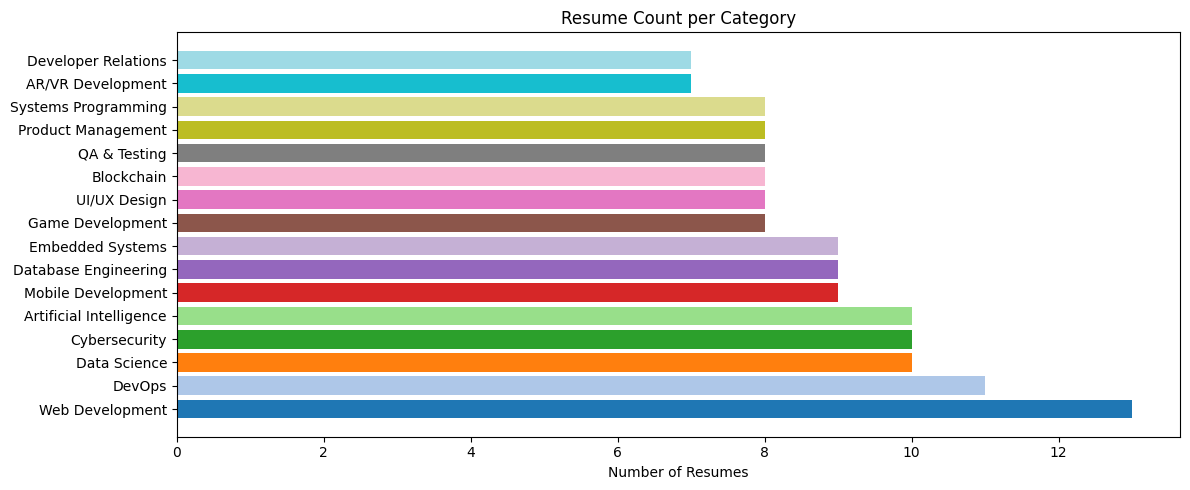

In [10]:
plt.figure(figsize=(12, 5))
counts = df['category'].value_counts()
colors = plt.cm.tab20(np.linspace(0, 1, len(counts)))
bars = plt.barh(counts.index, counts.values, color=colors)
plt.xlabel("Number of Resumes")
plt.title("Resume Count per Category")
plt.tight_layout()
plt.show()

In [6]:
from collections import Counter

print("Total classes:", len(np.unique(y)))
print(Counter(y))

NameError: name 'y' is not defined

In [12]:
def clean_text(text):
    text = text.lower()

    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)

    text = text.replace('c++', ' cpp ')
    text = text.replace('c#', ' csharp ')
    text = text.replace('.net', ' dotnet ')
    text = text.replace('node.js', ' nodejs ')
    text = text.replace('next.js', ' nextjs ')
    text = text.replace('react.js', ' reactjs ')
    text = text.replace('vue.js', ' vuejs ')
    text = text.replace('web3.js', ' web3js ')
    text = text.replace('scikit-learn', ' scikitlearn ')

    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    words = word_tokenize(text)

    words = [
        w for w in words
        if (w not in stop_words or w in TECH_KEEP)
        and (len(w) > 1 or w in TECH_KEEP)
    ]

    words = [
        lemmatizer.lemmatize(w)
        for w in words
    ]

    return ' '.join(words)

In [ ]:
tfidf = TfidfVectorizer(
    max_features  = 5000,
    ngram_range   = (1, 3),
    sublinear_tf  = True,
    min_df        = 1,
)

X = tfidf.fit_transform(df['clean'])
y = df['label'].values

print(f"Feature matrix: {X.shape[0]} samples x {X.shape[1]} features")

Feature matrix: 143 samples x 3030 features


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
)

print(f"Train : {X_train.shape[0]} samples")
print(f"Test  : {X_test.shape[0]} samples")

Train : 114 samples
Test  : 29 samples


In [ ]:
svm = CalibratedClassifierCV(LinearSVC(C=1.0, dual='auto', max_iter=2000))
lr  = LogisticRegression(C=5.0, max_iter=1000, solver='lbfgs')
rf  = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)

ensemble = VotingClassifier(
    estimators=[('svm', svm), ('lr', lr), ('rf', rf)],
    voting='soft'
)

models = {
    'LinearSVC'  : svm,
    'Logistic'   : lr,
    'RandomForest': rf,
    'Ensemble'   : ensemble,
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    cv_scores = cross_val_score(model, X, y, cv=3, scoring='accuracy')
    results[name] = {
        'train_acc': train_acc,
        'test_acc' : test_acc,
        'cv_mean'  : cv_scores.mean(),
        'cv_std'   : cv_scores.std(),
    }
    print(f"{name:<15}  train={train_acc*100:.1f}%  "
          f"test={test_acc*100:.1f}%  "
          f"cv={cv_scores.mean()*100:.1f}% ± {cv_scores.std()*100:.1f}%")

LinearSVC        train=100.0%  test=89.7%  cv=91.7% ± 5.1%
Logistic         train=100.0%  test=82.8%  cv=94.4% ± 3.9%
RandomForest     train=100.0%  test=89.7%  cv=89.5% ± 4.5%
Ensemble         train=100.0%  test=93.1%  cv=93.0% ± 5.5%


In [ ]:
best_name  = max(results, key=lambda k: results[k]['cv_mean'])
best_model = models[best_name]

print(f"Best model: {best_name}")
print(f"CV accuracy: {results[best_name]['cv_mean']*100:.2f}%")

Best model: Logistic
CV accuracy: 94.44%


In [ ]:
y_pred = best_model.predict(X_test)

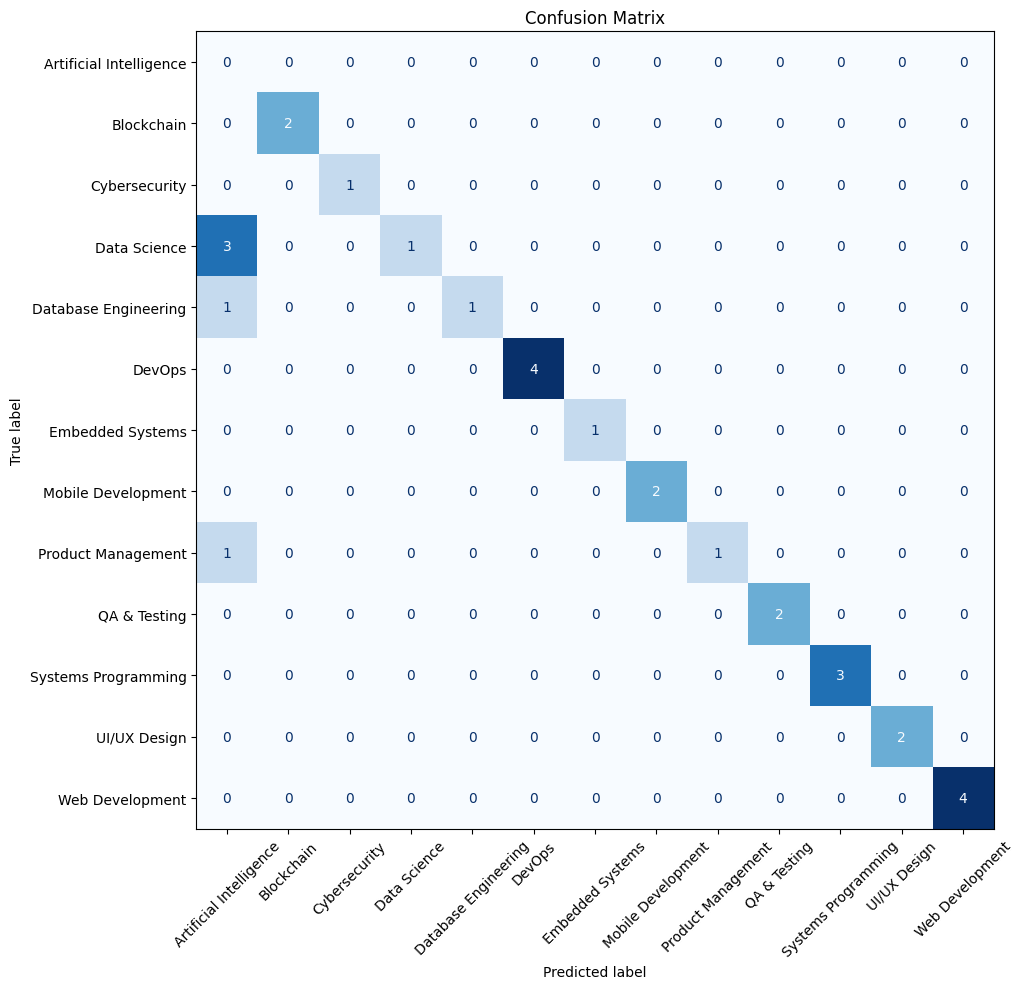

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


cm = confusion_matrix(y_test, y_pred)

all_classes = np.unique(np.concatenate((y_test, y_pred)))

labels = label_encoder.inverse_transform(all_classes)


fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap='Blues',
    colorbar=False
)

plt.title("Confusion Matrix")

plt.tight_layout()

plt.show()

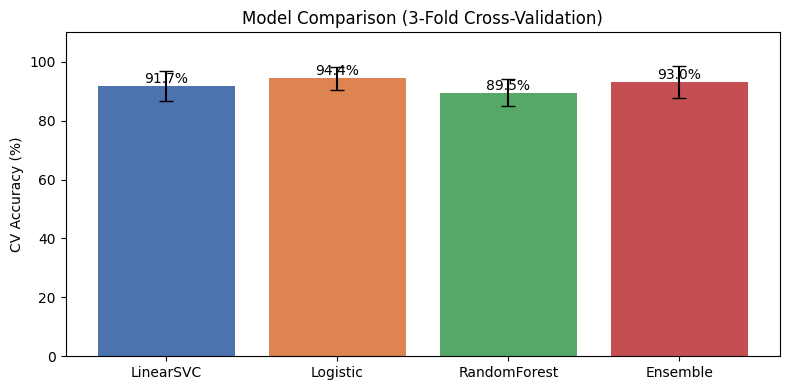

In [ ]:
names  = list(results.keys())
cv_acc = [results[n]['cv_mean']*100 for n in names]
cv_std = [results[n]['cv_std']*100  for n in names]

plt.figure(figsize=(8, 4))
bars = plt.bar(names, cv_acc, yerr=cv_std, capsize=5,
               color=['#4C72B0','#DD8452','#55A868','#C44E52'])
plt.ylabel("CV Accuracy (%)")
plt.title("Model Comparison (3-Fold Cross-Validation)")
plt.ylim(0, 110)
for bar, val in zip(bars, cv_acc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{val:.1f}%", ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
def predict_resume(text, top_n=3):
    cleaned = clean_text(text)
    vec     = tfidf.transform([cleaned])
    probs   = best_model.predict_proba(vec)[0]
    top_idx = np.argsort(probs)[::-1][:top_n]

    print(f"Input (cleaned): {cleaned[:80]}...")
    print()
    print(f"{'Rank':<6} {'Category':<28} {'Confidence'}")
    print("-" * 50)
    for rank, idx in enumerate(top_idx, 1):
        cat   = label_encoder.classes_[idx]
        score = probs[idx] * 100
        bar   = "█" * int(score // 5)
        print(f"  {rank}    {cat:<28} {score:5.1f}%  {bar}")
    print()
    return label_encoder.classes_[top_idx[0]]

In [ ]:
test_resumes = {
    "Data Science":
        "Python developer skilled in Machine Learning, Deep Learning, PyTorch, "
        "FastAPI, NLP, TensorFlow, REST APIs, pandas, scikit-learn",

    "Web Dev":
        "Built full-stack apps with React, Node.js, MongoDB, Express. "
        "Deployed on AWS using Docker and CI/CD pipelines.",

    "Cybersecurity":
        "Penetration tester with CEH certification. Experience in Kali Linux, "
        "Metasploit, Wireshark, OWASP top 10, and vulnerability assessments.",

    "Mobile":
        "Flutter developer with 2 years experience building iOS and Android apps. "
        "State management with BLoC, Firebase, REST APIs.",
}

for label, resume in test_resumes.items():
    print(f"=== {label} ===")
    predict_resume(resume)
    print()

=== Data Science ===
Input (cleaned): python developer skilled machine learning deep learning pytorch fastapi nlp tens...

Rank   Category                     Confidence
--------------------------------------------------
  1    Data Science                  36.2%  ███████
  2    Artificial Intelligence       14.6%  ██
  3    Web Development                5.3%  █


=== Web Dev ===
Input (cleaned): built full stack apps react node j mongodb express deployed aws using docker ci ...

Rank   Category                     Confidence
--------------------------------------------------
  1    Web Development               27.1%  █████
  2    DevOps                        11.0%  ██
  3    Artificial Intelligence        6.0%  █


=== Cybersecurity ===
Input (cleaned): penetration tester ceh certification experience kali linux metasploit wireshark ...

Rank   Category                     Confidence
--------------------------------------------------
  1    Cybersecurity                 23.4%  ████


In [ ]:
with open('tfidf_vectorizer.pkl',   'wb') as f: pickle.dump(tfidf,         f)
with open('resume_classifier.pkl',   'wb') as f: pickle.dump(best_model,    f)
with open('label_encoder.pkl',       'wb') as f: pickle.dump(label_encoder, f)

print("Models saved!")
print(f"  tfidf_vectorizer.pkl")
print(f"  resume_classifier.pkl  ({best_name})")
print(f"  label_encoder.pkl      ({len(label_encoder.classes_)} categories)")

Models saved!
  tfidf_vectorizer.pkl
  resume_classifier.pkl  (Logistic)
  label_encoder.pkl      (16 categories)
